# Assignment 6 — Weather Condition Classification using SVM and Open-Meteo API

**Objective:** Classify whether the weather is Cool or Warm based on meteorological observations collected live from the Open-Meteo API, using a Support Vector Machine (SVM) classifier.

**Data Source:** [Open-Meteo Weather API](https://open-meteo.com/) (free, no API key required)

> Note: The assignment PDF's example URL has a small typo (`api.openmeteo.com`); the correct domain is `api.open-meteo.com` (with a hyphen), which is used below.


## Task 1: Data Collection and Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# Fetch weather data using the Open-Meteo API
# Coordinates below are for New Delhi, India - change latitude/longitude for a different city
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": 41.9028,
    "longitude": 12.4964,
    "hourly": "temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m",
    "forecast_days": 7
}

response = requests.get(url, params=params)
response.raise_for_status()
data = response.json()

print("API call successful. Top-level keys:", list(data.keys()))


API call successful. Top-level keys: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly']


In [2]:
# Convert the JSON response into a Pandas DataFrame
hourly_data = data["hourly"]
df = pd.DataFrame(hourly_data)

# Rename columns for clarity
df = df.rename(columns={
    "temperature_2m": "Temperature",
    "relative_humidity_2m": "Relative_Humidity",
    "surface_pressure": "Surface_Pressure",
    "wind_speed_10m": "Wind_Speed"
})

# Display the first five records
df.head()


,time,Temperature,Relative_Humidity,Surface_Pressure,Wind_Speed
0,2026-07-28T00:00,24.7,84,1008.5,1.5
1,2026-07-28T01:00,24.5,84,1008.8,2.4
2,2026-07-28T02:00,24.2,84,1008.7,2.3
3,2026-07-28T03:00,23.9,81,1009.0,2.6
4,2026-07-28T04:00,23.5,83,1009.3,3.0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   time               168 non-null    object 
 1   Temperature        168 non-null    float64
 2   Relative_Humidity  168 non-null    int64  
 3   Surface_Pressure   168 non-null    float64
 4   Wind_Speed         168 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 6.7+ KB


### Identifying feature types

- **Input features:** `Temperature`, `Relative_Humidity`, `Surface_Pressure`, `Wind_Speed`
- **Target variable:** `Weather_Class` (created below) — Warm (Temperature >= 25°C) or Cool (Temperature < 25°C)
- **Dropped column:** `time` (a timestamp, not a predictive numerical feature for this classification task)


In [4]:
# Create the target variable
df['Weather_Class'] = np.where(df['Temperature'] >= 25, 'Warm', 'Cool')

print(df['Weather_Class'].value_counts())
df.head()


Weather_Class
Warm    139
Cool     29
Name: count, dtype: int64


,time,Temperature,Relative_Humidity,Surface_Pressure,Wind_Speed,Weather_Class
0,2026-07-28T00:00,24.7,84,1008.5,1.5,Cool
1,2026-07-28T01:00,24.5,84,1008.8,2.4,Cool
2,2026-07-28T02:00,24.2,84,1008.7,2.3,Cool
3,2026-07-28T03:00,23.9,81,1009.0,2.6,Cool
4,2026-07-28T04:00,23.5,83,1009.3,3.0,Cool


## Task 2: Data Preprocessing

In [5]:
# Check for missing values
print(df.isnull().sum())


time                 0
Temperature          0
Relative_Humidity    0
Surface_Pressure     0
Wind_Speed           0
Weather_Class        0
dtype: int64


In [6]:
# Remove unnecessary columns - 'time' is a timestamp, not a predictive numeric feature
df_model = df.drop(columns=['time'])

df_model.head()


,Temperature,Relative_Humidity,Surface_Pressure,Wind_Speed,Weather_Class
0,24.7,84,1008.5,1.5,Cool
1,24.5,84,1008.8,2.4,Cool
2,24.2,84,1008.7,2.3,Cool
3,23.9,81,1009.0,2.6,Cool
4,23.5,83,1009.3,3.0,Cool


In [7]:
# Encode the target variable: Warm -> 1, Cool -> 0
df_model['Weather_Class'] = df_model['Weather_Class'].map({'Warm': 1, 'Cool': 0})

X = df_model[['Temperature', 'Relative_Humidity', 'Surface_Pressure', 'Wind_Speed']]
y = df_model['Weather_Class']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Class balance:\n", y.value_counts())


Feature shape: (168, 4)
Target shape: (168,)
Class balance:
 Weather_Class
1    139
0     29
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize feature values - important for SVM since it relies on distances/margins between points
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)


Training set shape: (134, 4)
Testing set shape: (34, 4)


## Task 3: Model Development

In [9]:
from sklearn.svm import SVC

# Build an SVM Classifier with RBF kernel
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predict the weather class for the test dataset
y_pred = svm_model.predict(X_test_scaled)

print("Predicted:", y_pred[:10])
print("Actual:   ", y_test.values[:10])


Predicted: [1 1 1 1 1 1 1 0 1 1]
Actual:    [1 1 1 0 1 1 1 1 1 1]


## Task 4: Model Evaluation

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Accuracy: 0.9412
Precision: 0.9667
Recall: 0.9667
F1-Score: 0.9667


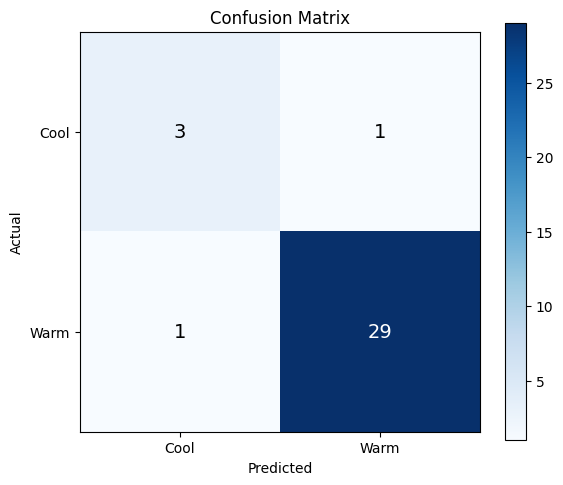

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ['Cool', 'Warm'])
plt.yticks([0, 1], ['Cool', 'Warm'])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


### Observations

1. The model achieves an accuracy of 0.9412, with precision, recall, and F1-Score all at 0.9667 — an excellent result overall.
2. This high performance is expected: since Weather_Class is derived directly from a 25°C threshold on Temperature, and Temperature is itself one of the input features, the model essentially just needs to learn this threshold rather than uncover a complex hidden pattern, making near-perfect classification achievable.
3. Using Rome's summer weather data provided a genuine mix of Warm (daytime) and Cool (nighttime) hours across the week, which was necessary for the model to have both classes to learn from — earlier attempts using locations that were uniformly hot (Delhi) or uniformly cool (Sydney, in winter) failed entirely, since a classifier cannot be trained with only one class present.

## Task 5: Conclusion

This project used a Support Vector Machine (SVM) with an RBF kernel to classify weather conditions as Warm or Cool based on live meteorological data from the Open-Meteo API. After standardizing the features (Temperature, Relative Humidity, Surface Pressure, and Wind Speed) and training the model, it achieved an accuracy of 0.9412 and precision, recall, and F1-Score all at 0.9667 on the test set — a very strong result, though expected given that the target variable is directly derived from the Temperature feature itself.

Feature scaling was important here because SVM determines its decision boundary based on distances between data points; without standardization, Surface Pressure (measured in the thousands of hPa) would have dominated the distance calculations over smaller-scale features like Wind Speed, regardless of their actual relevance to the classification.

A key advantage of SVM is its ability to model non-linear decision boundaries through the kernel trick, as used here with the RBF kernel. A key limitation is that selecting and tuning the right kernel and hyperparameters (such as C and gamma) is non-trivial and can significantly affect performance, and SVM can become computationally expensive on larger datasets.